In [4]:
import pandas as pd

df = pd.read_csv('taxis.csv')

df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   object 
 1   dropoff          6433 non-null   object 
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   object 
 9   payment          6389 non-null   object 
 10  pickup_zone      6407 non-null   object 
 11  dropoff_zone     6388 non-null   object 
 12  pickup_borough   6407 non-null   object 
 13  dropoff_borough  6388 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 703.7+ KB


In [7]:
df['pickup'] = pd.to_datetime(df['pickup'])
df['dropoff'] = pd.to_datetime(df['dropoff'])

In [10]:
df['hour'] = df['pickup'].dt.hour
df['day'] = df['pickup'].dt.day_name()

In [9]:
df['hour'].value_counts()

,count
hour,
18,417
19,406
17,388
20,368
14,360
21,355
16,336
12,334
15,330


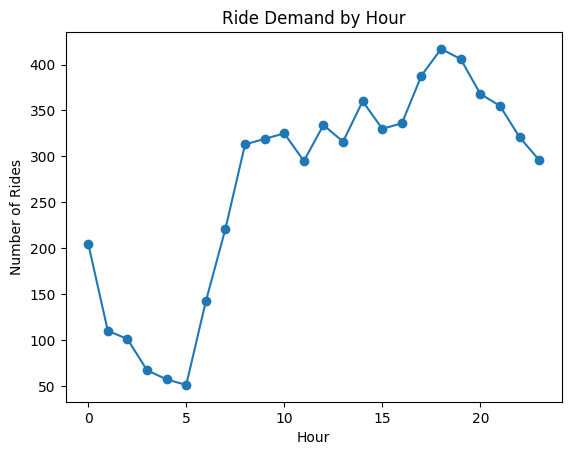

In [11]:
import matplotlib.pyplot as plt

df['hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Ride Demand by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Rides')
plt.show()

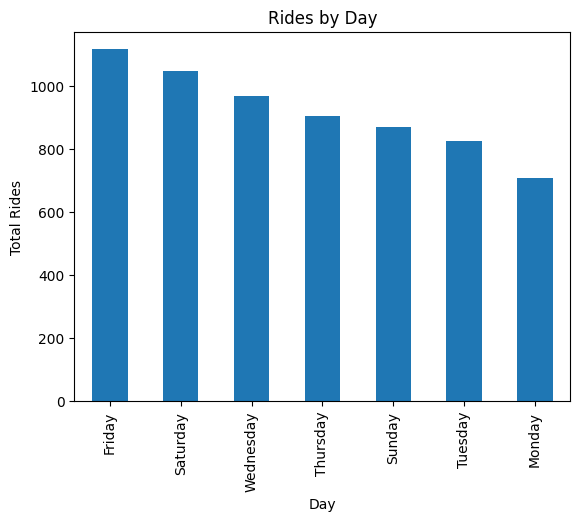

In [12]:
df['day'].value_counts().plot(kind='bar')
plt.title('Rides by Day')
plt.xlabel('Day')
plt.ylabel('Total Rides')
plt.show()

In [13]:
df['total'].sum()

np.float64(119124.97)

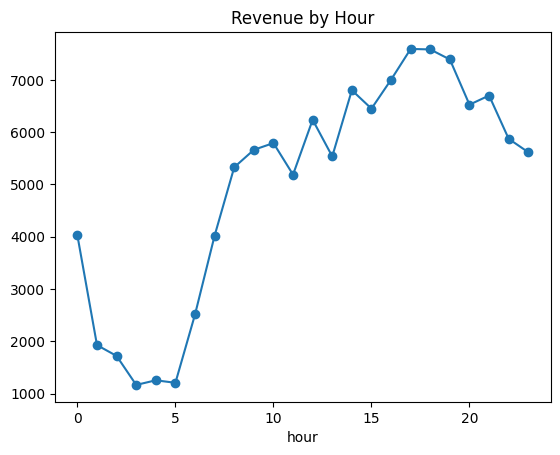

In [14]:
df.groupby('hour')['total'].sum().plot(kind='line', marker='o')
plt.title('Revenue by Hour')
plt.show()

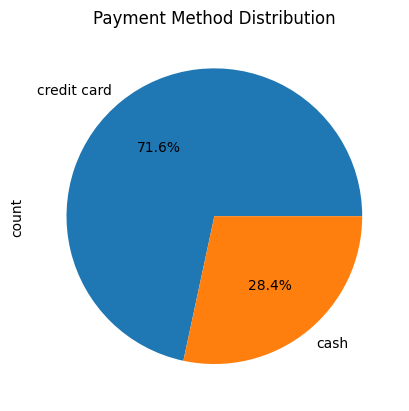

In [15]:
df['payment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

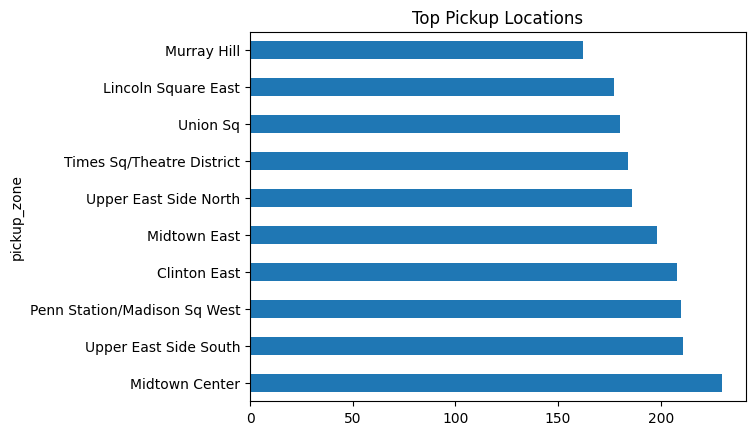

In [16]:
df['pickup_zone'].value_counts().head(10).plot(kind='barh')
plt.title('Top Pickup Locations')
plt.show()

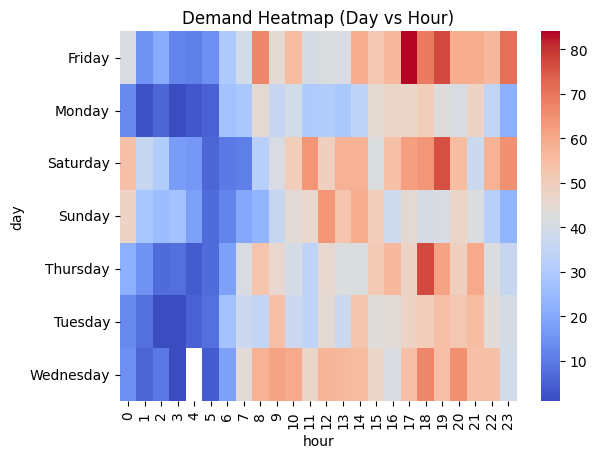

In [17]:
import seaborn as sns

pivot = df.pivot_table(index='day', columns='hour', values='total', aggfunc='count')

sns.heatmap(pivot, cmap='coolwarm')
plt.title('Demand Heatmap (Day vs Hour)')
plt.show()